# 03 — Reconstruct the Boudreau-like three-box model

**Learning goal.** Starting only from the flux diagram and a parameter table, construct the complete Boudreau-2010-like ESBMTK model yourself. You will decide which objects represent boxes, which connections represent arrows, which species each arrow carries, and in what order the coupled chemistry must be attached.

This notebook deliberately does **not** use the repository's `initialize_model` helper. Notebook 04 will use that tested implementation when the scientific question shifts from model construction to pump experiments.

## 1. Read the flux diagram as a model specification

```text
                                      Atmosphere: CO2
                                  ↙ gas exchange  ↘

 weathering ──> Low-latitude surface ──THC──> High-latitude surface
                 states: DIC, TA                   states: DIC, TA
                       │  ╲                             │   ↕ mixing
              POC: DIC │   ╲ PIC: DIC and 2 × TA      │
                       ▼    ╲                           ▼
                                      Deep ocean: DIC, TA
                                               │
                                   dissolution │ burial
                                               ▼
                                          sediment
```

Before writing code, classify every arrow:

- **Internal redistribution:** thermohaline circulation, mixing, POC export, PIC export, dissolution, and air–sea exchange move material between model reservoirs.
- **Boundary fluxes:** weathering enters the modeled ocean; permanent carbonate burial leaves it.
- **Calculated chemistry:** pH, aqueous CO₂, carbonate ion, saturation depth, compensation depth, and snowline follow from the prognostic DIC and TA states.

## 2. Translate symbols into ESBMTK objects

| Diagram element | Mathematical role | ESBMTK representation |
| --- | --- | --- |
| Simulation boundary and clock | common units and integration interval | `Model` |
| Three ocean boxes | DIC and TA inventories with geometry and water properties | `initialize_reservoirs` |
| Atmosphere | atmospheric carbon inventory expressed as pCO₂ | `GasReservoir` |
| Circulation and mixing | water transport multiplied by source concentration | `create_bulk_connections`, type `scale_with_concentration` |
| Soft-tissue pump | fixed transfer of DIC from low-latitude surface to depth | `POM` connection |
| Carbonate pump | paired surface losses of DIC and TA | `PIC_DIC` and `PIC_TA` connections |
| Carbonate equilibria | DIC and TA determine CO₂(aq), pH, and carbonate ion | carbonate system 1 |
| Carbonate compensation | rain, dissolution, burial, and depth diagnostics | carbonate system 2 |
| Air–sea CO₂ exchange | bidirectional atmosphere–surface carbon flux | `Species2Species`, type `gasexchange` |
| Weathering | fixed external DIC and TA supply | `ConnectionProperties` |

The order matters. Reservoirs must exist before connections can refer to them; surface carbonate chemistry must exist before gas exchange can use aqueous CO₂; and the PIC flux object must exist before carbonate system 2 can consume it.

## 3. Write the conservation equations first

For ocean box $i$ with water mass $m_i$, the two prognostic inventories obey

$$
m_i\frac{d[\mathrm{DIC}]_i}{dt}
=\sum J_{C,\mathrm{in}}-\sum J_{C,\mathrm{out}},
$$

$$
m_i\frac{d[\mathrm{TA}]_i}{dt}
=\sum J_{\mathrm{TA},\mathrm{in}}-\sum J_{\mathrm{TA},\mathrm{out}}.
$$

A transport coefficient $q_{i\rightarrow j}$ in kg/yr carries constituent $X$ at the source concentration (mol/kg),

$$
J^{(X)}_{i\rightarrow j}(t)=q_{i\rightarrow j}[X]_i(t).
$$

The soft-tissue closure exports carbon without TA. Calcification removes one mole of DIC and two equivalents of TA for every mole of CaCO₃,

$$
J_{\mathrm{PIC,TA}}=2J_{\mathrm{PIC,DIC}}.
$$

Dissolution reverses that stoichiometry. Consequently, carbonate export must be represented by a linked DIC–TA pair, never by two independently chosen rates.

**Benchmark unit convention.** For a physical water transport $Q$ in m3/yr,
$q=Q\rho$. The archived ESBMTK benchmark instead passes volume scales through
the native mapper, which converts them to litres/yr; that numerical coefficient
multiplies the mol/kg state. We retain this historical nominal conversion for
benchmark reproduction. The ODE reservoir masses still use each box's ESBMTK
density. Practical 02 explicitly supplies $Q\rho$ in kg/yr. Changing the
benchmark transport convention would be a separate sensitivity experiment.


In [1]:
from pathlib import Path
import sys
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name in {'instructor', 'student'}:
    ROOT = ROOT.parents[1]
elif ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from esbmtk import (
    Q_, ConnectionProperties, GasReservoir, Model, Species2Species,
    add_carbonate_system_1, add_carbonate_system_2,
    create_bulk_connections, initialize_reservoirs,
)
from model import postprocess_carbonate_horizons, run_model, standard_diagnostics
from presets import load_boudreau_parameters
from reservoir_inputs import reservoir_inventory_rows
from model_inputs import read_model_tables

WORKBOOK = ROOT / 'data' / 'Boudreau_2010' / 'model_definition.xlsx'
P = load_boudreau_parameters(WORKBOOK)
input_tables = read_model_tables(WORKBOOK)
STATE = ROOT / 'data' / 'Boudreau_2010' / 'steady_state'

## 4. Read the model workbook

Open [model_definition.xlsx](../../data/Boudreau_2010/model_definition.xlsx). Its four sheets specify the baseline:

| Sheet | Model information |
| --- | --- |
| Reservoirs | Ocean and atmospheric inventories, explicit areas/volumes, water properties, and boundary nodes |
| Transport | Source, sink, process ID and parameter name for each directed water-transport arrow |
| GasExchange | The atmosphere–surface connections and their rate parameter |
| Parameters | Transport/export/weathering rates, carbonate options and optional feedback parameters |

These are the model inputs. The notebook supplies process equations, construction exercises, and checks. `presets.py` reads a fresh workbook and prepares independent experiment copies; it contains no duplicate baseline parameter values.

**Geometry:** use the area and volume columns directly. The adapter preserves these benchmark inputs, so no area fractions or depth-based conversion are needed. As in 01/02, the supplied geometry is explicit, but 03/04 retain their own benchmark sizes and box-specific thermodynamic conditions.

Keep box IDs `L_b`, `H_b`, `D_b`, `CO2_At`, `Fw`, and `Fb`. The restart and specialized process equations use these names. DIC and TA in Excel are prescribed initial concentrations, not predicted equilibria or independent validation targets. Feedback normalization values are labelled separately from prescribed rates.

Save Excel edits and rerun setup and all construction cells. Input table cells require literal values; the derived PIC and weathering-TA formula cells are readouts. Python recomputes those relationships from their inputs. Keep the supplied values for benchmark reproduction. Changed geometry, chemistry or baseline process rates requires a new stationary restart before interpreting perturbations.


In [2]:
display(pd.DataFrame(input_tables['OceanReservoirs']).set_index('Box ID'))
display(pd.DataFrame(input_tables['Atmosphere']).set_index('Box ID'))
display(pd.DataFrame(input_tables['BoundaryNodes']).set_index('Box ID'))
display(pd.DataFrame(input_tables['ProcessParameters']).set_index('Parameter'))
print('Derived PIC:', P['pic_export'], '; weathering TA:', P['weathering_ta'])

,Description,Area (m2),Volume (m3),Temperature (degC),Salinity,Pressure (bar),Initial DIC (umol/kg),Initial TA (umol/kg)
Box ID,,,,,,,,
H_b,High-latitude surface,50000000000000,17600000000000000,2.0,35,17.6,2153,2345
L_b,Low-latitude surface,285000000000000,28500000000000000,21.5,35,5.0,1952,2288
D_b,Deep ocean,336000000000000,1290000000000000000,2.0,35,240.0,2291,2399


,Total air (mol),Initial CO2 (ppm),Role
Box ID,,,
CO2_At,177860000000000000000,280,Prognostic CO2


,Type,Species,Role
Box ID,,,
Fw,Source,"DIC, TA",External weathering supply
Fb,Sink,"DIC, TA",Permanent burial boundary


,Value,Unit,Role,Description
Parameter,,,,
thc,25.00000,Sverdrup,Prescribed transport,Water transport on every leg of the overturnin...
mixing,30.00000,Sverdrup,Prescribed transport,Equal exchange in both directions between high...
poc_export,200.00000,Tmol/yr,Prescribed export,POC carbon export from low-latitude surface to...
rain_ratio,0.30000,1,Prescribed ratio,PIC/POC carbon-export ratio at unit pump stren...
weathering_dic,12.00000,Tmol/yr,Prescribed boundary flux,Carbonate weathering: one DIC and two TA equiv...
alpha,0.60000,1,Benchmark coefficient,Carbonate compensation coefficient
z0,-200.00000,m,Benchmark elevation,Carbonate compensation reference elevation
piston_velocity,4.80000,m/d,Prescribed exchange rate,Common gas transfer velocity at both surface b...
opt_k_carbonic,13.00000,1,Chemistry choice,PyCO2SYS carbonic-acid constant option


Derived PIC: 60 Tmol/yr ; weathering TA: 24 Tmol/yr


In [3]:
# The loader attaches ESBMTK units but creates no reservoirs.
display(pd.DataFrame(P['boxes']).T)

,dic,ta,area,volume,temperature,pressure,salinity
H_b,2153 umol/kg,2345 umol/kg,50000000000000 m**2,17600000000000000 m**3,2.0,17.6,35.0
L_b,1952 umol/kg,2288 umol/kg,285000000000000 m**2,28500000000000000 m**3,21.5,5.0,35.0
D_b,2291 umol/kg,2399 umol/kg,336000000000000 m**2,1.29e+18 m**3,2.0,240.0,35.0


In [4]:
# Follow one spreadsheet value into the Python record.
print('High-latitude initial DIC:', P['boxes']['H_b']['dic'])

High-latitude initial DIC: 2153 umol/kg


## 5. Create the simulation container

`Model` is not a physical reservoir. It defines time, units, elements, and carbonate-constant options shared by all later objects. Include Carbon, Boron, Hydrogen, and miscellaneous variables because the carbonate modules require them.

In [5]:
# Exercise 03.1: translate the numerical-model boundary into Model(...).
# BEGIN SOLUTION
M = Model(
    stop='20 yr',
    max_timestep='1 yr',
    element=['Carbon', 'Boron', 'Hydrogen', 'misc_variables'],
    mass_unit='mol',
    concentration_unit='mol/kg',
    opt_k_carbonic=P['opt_k_carbonic'],
    opt_pH_scale=P['opt_pH_scale'],
)
# END SOLUTION

assert M.stop == Q_('20 yr').to(M.t_unit).magnitude
assert M.DIC.name == 'DIC' and M.TA.name == 'TA'


ESBMTK 0.14.3.1.post0  
 Copyright (C) 2020 - 2026  Ulrich G.Wortmann
This program comes with ABSOLUTELY NO WARRANTY
This is free software, and you are welcome to redistribute it
under certain conditions; See the LICENSE file for details.

If you use ESBMTK for your research, please cite:

Wortmann et al. 2025, https://doi.org/10.5194/gmd-18-1155-2025



## 6. Turn the three boxes into reservoirs

For each box, ESBMTK needs initial concentrations (`c`), geometry (`g`), temperature (`T`), pressure (`P`), and salinity (`S`). The weathering source and burial sink have no water volume: they mark fluxes that cross the system boundary.

`initialize_reservoirs` returns the species list used by the physical water transports. Passing that list makes circulation carry both DIC and TA.

**One-row example (supplied):** the next cell maps the high-latitude row to ESBMTK fields. It prepares a specification only. In Exercise 03.2, generalize this mapping to all three rows, add the two boundary nodes, and call `initialize_reservoirs` once.

In [6]:
# Supplied example: Excel row -> Python record -> ESBMTK specification.
high = P['boxes']['H_b']
high_specification = {
    'c': {M.DIC: high['dic'], M.TA: high['ta']},
    'g': {'area': high['area'], 'volume': high['volume']},
    'T': high['temperature'],
    'P': high['pressure'],
    'S': high['salinity'],
}
high_specification

{'c': {: '2153 umol/kg', : '2345 umol/kg'},
 'g': {'area': '50000000000000 m**2', 'volume': '17600000000000000 m**3'},
 'T': 2.0,
 'P': 17.6,
 'S': 35.0}

In [7]:
# Exercise 03.2: translate the three box records and two boundary nodes.
# BEGIN SOLUTION
box_parameters = {}
for box_name, box in P['boxes'].items():
    box_parameters[box_name] = {
        'c': {M.DIC: box['dic'], M.TA: box['ta']},
        'g': {'area': box['area'], 'volume': box['volume']},
        'T': box['temperature'],
        'P': box['pressure'],
        'S': box['salinity'],
    }

for node in P['boundary_nodes']:
    box_parameters[node['name']] = {
        'ty': node['type'],
        'sp': [getattr(M, species) for species in node['species']],
    }
species_list = initialize_reservoirs(M, box_parameters)
# END SOLUTION

assert {M.L_b.name, M.H_b.name, M.D_b.name} == {'L_b', 'H_b', 'D_b'}
assert set(species_list) == {M.DIC, M.TA}
for box in (M.L_b, M.H_b, M.D_b):
    assert hasattr(box, 'DIC') and hasattr(box, 'TA')

### Check the implemented reservoir inventories

ESBMTK calculates density from each box’s temperature, salinity and pressure. Water mass is volume times this density. The table below shows the resulting water mass and initial carbon/TA amounts. These are software and inventory checks, not extra fitted inputs.

In [8]:
display(pd.DataFrame(reservoir_inventory_rows(M)).set_index('Box'))

,Density (kg/m3),Water mass (kg),Initial carbon (mol),Initial TA (mol eq)
Box,,,,
H_b,1028.798771,1.810686e+19,3.898407e+16,4.246058e+16
L_b,1024.575722,2.920041e+19,5.699920e+16,6.681053e+16
D_b,1038.983451,1.340289e+21,3.070601e+18,3.215352e+18


## 7. Turn circulation arrows into concentration-scaled connections

The thermohaline loop is `L_b → H_b → D_b → L_b`, with 25 Sv on every leg. The separate 30 Sv exchange is `H_b ↔ D_b`. Each arrow uses the **source** concentration. Equal transports in opposing or closed paths conserve water and transport both DIC and TA.

Connection names use `source_to_sink@id`. The part after `@` becomes a readable process identifier for later inspection.

The Transport sheet lists both mixing directions explicitly. Parameter names refer to the Parameters sheet, so the common overturning rate is entered once. Trace each row on the diagram and check that every box gains and loses equal water before constructing the arrows. `Order` preserves the construction sequence if you sort Excel rows.

In [9]:
# Inspect the directed arrows supplied by Excel.
display(pd.DataFrame(input_tables['TransportConnections']).sort_values('Order'))

# Exercise 03.3: map each transport row to an ESBMTK connection.
# Use source, sink, id, and P[row['parameter']]. Carry both DIC and TA.
# BEGIN SOLUTION
connection_parameters = {}
for row in P['transport_connections']:
    name = f"{row['source']}_to_{row['sink']}@{row['id']}"
    connection_parameters[name] = {
        'ty': 'scale_with_concentration',
        'sc': P[row['parameter']],
        'sp': species_list,
    }
create_bulk_connections(connection_parameters, M)
# END SOLUTION

assert len(M.loc) == 2 * len(P['transport_connections'])
for row in P['transport_connections']:
    connections = [conn for conn in M.loc if conn.id == row['id']
                   and conn.source.parent.name == row['source']
                   and conn.sink.parent.name == row['sink']]
    assert len(connections) == 2


,Order,source,sink,flux_id,Parameter,Species
0,1,H_b,D_b,mix_down,mixing,"DIC, TA"
1,2,D_b,H_b,mix_up,mixing,"DIC, TA"
2,3,L_b,H_b,thc,thc,"DIC, TA"
3,4,H_b,D_b,thc,thc,"DIC, TA"
4,5,D_b,L_b,thc,thc,"DIC, TA"


## 8. Turn the two pump arrows into fixed fluxes

This baseline uses fixed exports. The POC closure moves DIC from the productive low-latitude surface to the deep ocean. PIC removes low-latitude DIC and TA; its nominal DIC sink is bypassed later by carbonate system 2, which partitions the rain between dissolution and burial.

The rain ratio is a diagnostic,

$$
r_{\mathrm{rain}}=\frac{J_{\mathrm{PIC}}}{J_{\mathrm{POC}}}
=\frac{60}{200}=0.3.
$$

Use one quantity for the PIC DIC rate and multiply it by two for the TA rate. This keeps the stoichiometry exact.

In [10]:
# Exercise 03.4: encode POC and the stoichiometrically linked PIC pair.
# BEGIN SOLUTION
M.tutorial_params = P
M.OM_export_reference = Q_(P['poc_export'])
M.CaCO3_export_reference = Q_(P['pic_export'])
M.OM_export = M.OM_export_reference
M.CaCO3_export = M.CaCO3_export_reference

create_bulk_connections(
    {
        'L_b_to_D_b@POM': {
            'sp': M.DIC, 'ty': 'Fixed', 'ra': M.OM_export,
        },
        'L_b_to_D_b@PIC_DIC': {
            'sp': M.DIC, 'ty': 'Fixed', 'ra': M.CaCO3_export, 'bp': 'sink',
        },
        'L_b_to_D_b@PIC_TA': {
            'sp': M.TA, 'ty': 'Fixed', 'ra': M.CaCO3_export * 2, 'bp': 'sink',
        },
    },
    M,
)

M.OM_export_flux = M.flux_summary(filter_by='POM', return_list=True)[0]
M.CaCO3_export_flux = M.flux_summary(filter_by='PIC_DIC', return_list=True)[0]
M.rain_ratio = (
    M.CaCO3_export.to('Tmol/yr').magnitude
    / M.OM_export.to('Tmol/yr').magnitude
)
# END SOLUTION

poc_connections = [c for c in M.loc if c.id == 'POM']
pic_dic_connections = [c for c in M.loc if c.id == 'PIC_DIC']
pic_ta_connections = [c for c in M.loc if c.id == 'PIC_TA']
assert len(poc_connections) == len(pic_dic_connections) == len(pic_ta_connections) == 1
assert pic_ta_connections[0].rate == 2 * pic_dic_connections[0].rate
assert M.rain_ratio == P['rain_ratio']

## 9. Attach carbonate chemistry and compensation

Carbonate system 1 calculates fast aqueous speciation from DIC and TA in both surface boxes. Carbonate system 2 represents deep carbonate saturation, dissolution, and burial. It needs the **PIC flux object**, not merely the number 60 Tmol yr$^{-1}$, because notebook 04 will allow that flux to vary through time.

This is the key wiring relation:

$$
J_{\mathrm{PIC}}(t)\longrightarrow
\{J_{\mathrm{diss}}(t),J_{\mathrm{burial}}(t),z_{\mathrm{sat}}(t),z_{\mathrm{cc}}(t),z_{\mathrm{snow}}(t)\}.
$$

In [11]:
# Exercise 03.5: add surface chemistry, then connect PIC rain to the deep module.
# BEGIN SOLUTION
add_carbonate_system_1([M.L_b, M.H_b])
add_carbonate_system_2(
    r_sb=[M.L_b],
    r_db=[M.D_b],
    carbonate_export_fluxes=[M.CaCO3_export_flux],
    z0=P['z0'],
    alpha=P['alpha'],
)
# END SOLUTION

assert hasattr(M.L_b, 'CO2aq') and hasattr(M.H_b, 'CO2aq')
assert M.D_b.cs2.function_input_data[0] is M.CaCO3_export_flux

### 9.1 What the three depths mean

All depths are reported as positive metres below sea level.

| Quantity | Meaning | Type in this model |
| --- | --- | --- |
| $z_{\mathrm{sat}}$ | **Calcite saturation horizon:** depth where the water column changes from supersaturated to undersaturated, $\Omega_{\mathrm{calcite}}=1$ | algebraic diagnostic |
| $z_{\mathrm{cc}}$ | **Carbonate compensation depth:** idealized depth at which the arriving modern carbonate rain is completely dissolved | algebraic diagnostic |
| $z_{\mathrm{snow}}$ | **Carbonate snowline:** deepest boundary of the existing reactive CaCO₃ sediment inventory | prognostic state with memory |

Thus $z_{\mathrm{sat}}$ and $z_{\mathrm{cc}}$ respond immediately to current deep-ocean chemistry and export. The snowline can lag because previously deposited carbonate must dissolve before the sediment boundary moves upward. At the preindustrial steady state, $z_{\mathrm{snow}}$ lies close to $z_{\mathrm{cc}}$.

### 9.2 How ESBMTK calculates $z_{\mathrm{sat}}$ and $z_{\mathrm{cc}}$

Carbonate system 2 first calculates deep carbonate ion from deep DIC, TA, and hydrogen ion,

$$
[\mathrm{CO_3^{2-}}]
=\frac{[\mathrm{DIC}]}
{1+[\mathrm{H^+}]/K_2+[\mathrm{H^+}]^2/(K_1K_2)}.
$$

Pressure makes calcite less soluble upward and more soluble downward. ESBMTK represents the saturation carbonate concentration with a depth lookup table and solves the saturation condition $[\mathrm{Ca^{2+}}][\mathrm{CO_3^{2-}}]=K_{sp}(z)$. The implemented solution is

$$
z_{\mathrm{sat}}
=z_{\mathrm{sat},0}
\ln\left(
\frac{[\mathrm{Ca^{2+}}][\mathrm{CO_3^{2-}}]}{K_{sp,0}}
\right),
$$

clipped between the top of the sediment domain and the maximum ocean depth.

The compensation depth also depends on the total PIC rain $F_{\mathrm{export}}$,

$$
z_{\mathrm{cc}}
=z_{\mathrm{sat},0}
\ln\left(
\frac{F_{\mathrm{export}}[\mathrm{Ca^{2+}}]}
{K_{sp,0}A_Dk_c}
+\frac{[\mathrm{Ca^{2+}}][\mathrm{CO_3^{2-}}]}{K_{sp,0}}
\right).
$$

Here $A_D$ is the hypsometric seafloor area between $z_0$ and $z_{\max}$, and $k_c$ is the calcite dissolution coefficient. Lower deep-ocean carbonate makes both horizons shallower; greater carbonate rain makes $z_{\mathrm{cc}}$ deeper because more material can survive dissolution.

### 9.3 From ocean hypsometry to dissolution and burial

The model uses one-metre lookup tables for seafloor area and the carbonate concentration required for saturation. It divides the seafloor into chemically distinct depth intervals:

```text
z0                 zsat                    zcc                 zsnow       zmax
│ supersaturated     │ undersaturated        │ no modern rain     │ old CaCO3 │
│ background term    │ kinetic dissolution   │ survives           │ may dissolve
└────────────────────┴───────────────────────┴────────────────────┴────────────
```

The mean carbonate rain per unit depositional area is

$$
B_{A_D}=\frac{F_{\mathrm{export}}}{A_D}.
$$

ESBMTK sums four contributions: a prescribed background response above $z_{\mathrm{sat}}$, undersaturation-driven dissolution between $z_{\mathrm{sat}}$ and $z_{\mathrm{cc}}$, complete dissolution of modern rain below $z_{\mathrm{cc}}$, and dissolution of pre-existing sediment when $z_{\mathrm{snow}}>z_{\mathrm{cc}}$. In compact form,

$$
F_{\mathrm{diss}}
=B_{\mathrm{NS}}+B_{\mathrm{DS}}+B_{\mathrm{CC}}+B_{\mathrm{PDC}},
$$

$$
F_{\mathrm{burial}}
=F_{\mathrm{export}}-F_{\mathrm{diss}}.
$$

The dissolved fraction returns to the deep ocean as one DIC plus two TA equivalents per mole of CaCO₃,

$$
J_{\mathrm{deep,DIC}}=F_{\mathrm{diss}},
\qquad
J_{\mathrm{deep,TA}}=2F_{\mathrm{diss}}.
$$

The PIC connection was created with `bp='sink'`, so its nominal deep-ocean sink is bypassed. Carbonate system 2 adds only the dissolved fraction back to the water. The undissolved residual has therefore left the active ocean inventory and represents burial. There is no explicit sediment reservoir in carbonate system 2; a model requiring explicit sediment mass would need a different module.

### 9.4 Why $z_{\mathrm{snow}}$ is different

The snowline is initialized near 4750 m and is registered as an ESBMTK state variable. When the instantaneous compensation depth becomes deeper than the snowline, the snowline relaxes downward toward it. When the snowline is deeper than the compensation depth, previously deposited carbonate between them dissolves and the boundary shoals according to

$$
\frac{dz_{\mathrm{snow}}}{dt}
=-\frac{B_{\mathrm{PDC}}}
{A(z_{\mathrm{snow}})I_{\mathrm{CaCO_3}}},
$$

where $A(z_{\mathrm{snow}})$ is seafloor area per depth interval and $I_{\mathrm{CaCO_3}}$ is the dissolvable sediment inventory per unit area. This prognostic boundary gives carbonate compensation its memory and long response time.

During integration, carbonate system 2 repeatedly calculates the instantaneous $z_{\mathrm{sat}}$, $z_{\mathrm{cc}}$, and dissolution flux needed by the ODE, but only $z_{\mathrm{snow}}$ is retained as a dynamic state. After integration, `postprocess_carbonate_horizons` reconstructs the saved $z_{\mathrm{sat}}$, $z_{\mathrm{cc}}$, $F_{\mathrm{diss}}$, and $F_{\mathrm{burial}}$ series from the stored chemistry, PIC flux, and already-integrated snowline.

In [12]:
# Inspect the constants and lookup-table dimensions supplied to carbonate system 2.
_, sediment_constants, area_table, area_dz_table, saturation_table = (
    M.D_b.cs2.function_params
)
(
    Ksp0, kc, depositional_area, zsat0, sediment_inventory,
    alpha, zsat_min, zmax, z0,
) = sediment_constants

pd.Series({
    'top of sediment domain z0 (m)': z0,
    'minimum saturation depth (m)': zsat_min,
    'maximum modeled depth (m)': zmax,
    'characteristic depth zsat0 (m)': zsat0,
    'depositional area AD (m2)': depositional_area,
    'dissolution coefficient kc': kc,
    'reactive CaCO3 inventory (mol/m2)': sediment_inventory,
    'background response alpha': alpha,
    'hypsometry lookup entries': len(area_table),
    'saturation lookup entries': len(saturation_table),
})

top of sediment domain z0 (m)        2.000000e+02
minimum saturation depth (m)         2.000000e+02
maximum modeled depth (m)            1.099900e+04
characteristic depth zsat0 (m)       5.078000e+03
depositional area AD (m2)            3.359584e+14
dissolution coefficient kc           8.840000e+03
reactive CaCO3 inventory (mol/m2)    5.290000e+02
background response alpha            6.000000e-01
hypsometry lookup entries            1.100000e+04
saturation lookup entries            1.099900e+04
dtype: float64

### 9.5 Prediction check

Predict the direction of change before running an acidification perturbation: what happens to $z_{\mathrm{sat}}$, $z_{\mathrm{cc}}$, dissolution, burial, and—more slowly—$z_{\mathrm{snow}}$ when deep-ocean carbonate ion decreases?

<!-- BEGIN SOLUTION -->
Lower carbonate ion reduces the calcite saturation ratio. Both $z_{\mathrm{sat}}$ and $z_{\mathrm{cc}}$ move upward, a larger fraction of seafloor becomes undersaturated, dissolution increases, and burial decreases. If the new compensation depth remains shallower than the existing snowline, old sediment dissolves and $z_{\mathrm{snow}}$ gradually shoals toward the new state.
<!-- END SOLUTION -->

## 10. Add the atmosphere and two gas-exchange arrows

`GasReservoir` stores atmospheric CO₂ as a mixing ratio. Each surface box exchanges independently with that common atmosphere. The sign of the flux is calculated from disequilibrium; `source` and `sink` define bookkeeping, not a permanently one-way arrow.

A schematic form of the exchange law is

$$
J_{\mathrm{gas}}=kA\left(K_0p\mathrm{CO}_2-[\mathrm{CO_2(aq)}]\right),
$$

where the solubility $K_0$ depends on the local surface temperature and salinity. The model's solubility pump therefore emerges from chemistry, gas exchange, and circulation rather than from one explicit pump flux.

In [13]:
display(pd.DataFrame(input_tables['GasExchangeConnections']).sort_values('Order'))

# Exercise 03.6: create the atmosphere and connect it to both surface boxes.
# BEGIN SOLUTION
GasReservoir(
    name='CO2_At', species=M.CO2, species_ppm=P['pco2'],
    reservoir_mass=P['atmosphere_moles'],
)

for row in P['gas_exchange_connections']:
    surface_box = getattr(M, row['surface'])
    Species2Species(
        source=getattr(M, row['atmosphere']),
        sink=surface_box.DIC,
        species=getattr(M, row['species']),
        piston_velocity=P[row['parameter']],
        ctype='gasexchange',
        id=surface_box.name,
    )
# END SOLUTION

gas_connections = [c for c in M.loc if c.ctype == 'gasexchange']
assert len(gas_connections) == 2
assert {c.sink for c in gas_connections} == {M.L_b.DIC, M.H_b.DIC}

,Order,Atmosphere,Surface,Species,Parameter
0,1,CO2_At,H_b,CO2,piston_velocity
1,2,CO2_At,L_b,CO2,piston_velocity


## 11. Close the long-term boundary budget with weathering

Weathering supplies DIC and TA to the low-latitude surface in a 1:2 ratio,

$$
J_{\mathrm{weathering,TA}}=2J_{\mathrm{weathering,DIC}}.
$$

At long-term steady state, carbonate burial balances this external supply. This explains why a permanent zero-carbonate-pump case cannot reach the original TA steady state while weathering remains active.

In [14]:
# Exercise 03.7: translate the external weathering arrow.
# BEGIN SOLUTION
ConnectionProperties(
    source=M.Fw,
    sink=M.L_b,
    rate={M.DIC: P['weathering_dic'], M.TA: P['weathering_ta']},
    species=[M.DIC, M.TA],
    ctype='fixed',
    id='weathering',
)
# END SOLUTION

weathering = [c for c in M.loc if c.id == 'weathering']
assert len(weathering) == 2

## 12. Audit the object graph before integrating

A model that runs is not necessarily the model in the diagram. Inspect the constructed graph and check counts, sources, sinks, transported species, and the PIC–sediment coupling before trusting a numerical result.

In [15]:
connection_table = pd.DataFrame([
    {
        'id': c.id,
        'source': c.source.full_name,
        'sink': c.sink.full_name,
        'type': c.ctype,
    }
    for c in M.loc
])

assert set(connection_table['id']) >= {
    'thc', 'mix_up', 'mix_down', 'POM', 'PIC_DIC', 'PIC_TA',
    'L_b', 'H_b', 'weathering',
}
connection_table.sort_values(['id', 'source']).reset_index(drop=True)

,id,source,sink,type
0,H_b,M.CO2_At,M.H_b.DIC,gasexchange
1,L_b,M.CO2_At,M.L_b.DIC,gasexchange
2,PIC_DIC,M.L_b.DIC,M.D_b.DIC,regular
3,PIC_TA,M.L_b.TA,M.D_b.TA,regular
4,POM,M.L_b.DIC,M.D_b.DIC,regular
5,mix_down,M.H_b.DIC,M.D_b.DIC,scale_with_concentration
6,mix_down,M.H_b.TA,M.D_b.TA,scale_with_concentration
7,mix_up,M.D_b.DIC,M.H_b.DIC,scale_with_concentration
8,mix_up,M.D_b.TA,M.H_b.TA,scale_with_concentration
9,thc,M.D_b.DIC,M.L_b.DIC,scale_with_concentration


## 13. Load the archived preindustrial state and test stationarity

The archived state avoids repeating the one-million-year benchmark spin-up during class. Loading it is not a substitute for construction: the restart only supplies concentrations and inventories; the flux graph you built still determines every tendency.

An unforced 20-year integration should show only very small numerical drift. A large trend usually means an arrow, species, direction, or stoichiometric factor was translated incorrectly.

In [16]:
M.read_state(directory=str(STATE))
initial = {
    'atmospheric pCO2 (ppm)': M.CO2_At.c[0] * 1e6,
    'low-latitude DIC (umol/kg)': M.L_b.DIC.c[0] * 1e6,
    'low-latitude TA (umol/kg)': M.L_b.TA.c[0] * 1e6,
}

run_model(M)
postprocess_carbonate_horizons(M)

final = {
    'atmospheric pCO2 (ppm)': M.CO2_At.c[-1] * 1e6,
    'low-latitude DIC (umol/kg)': M.L_b.DIC.c[-1] * 1e6,
    'low-latitude TA (umol/kg)': M.L_b.TA.c[-1] * 1e6,
}

pd.DataFrame({
    'initial': initial,
    'final': final,
    'change': {key: final[key] - initial[key] for key in initial},
})

status=0
message=The solver successfully reached the end of the integration interval.


 Execution took 0.06 CPU seconds, wall time = 0.61 seconds



,initial,final,change
atmospheric pCO2 (ppm),269.909720,269.909715,-0.000006
low-latitude DIC (umol/kg),1941.004851,1941.004893,0.000042
low-latitude TA (umol/kg),2282.228508,2282.228569,0.000061


### 13.1 Verify the reconstructed sediment budget

The post-processing step has now attached all five sediment diagnostics to `M.D_b`. Check both the ordering of the horizons and the carbonate-rain budget at every saved time point.

In [17]:
sediment_table = pd.DataFrame({
    'zsat (m)': M.D_b.zsat.c,
    'zcc (m)': M.D_b.zcc.c,
    'zsnow (m)': M.D_b.zsnow.c,
    'PIC export (Tmol/yr)': M.D_b.CaCO3_export.c / 1e12,
    'dissolution (Tmol/yr)': M.D_b.Fdiss.c / 1e12,
    'burial (Tmol/yr)': M.D_b.Fburial.c / 1e12,
})

budget_residual = (
    M.D_b.CaCO3_export.c - M.D_b.Fdiss.c - M.D_b.Fburial.c
)
assert abs(budget_residual).max() < 1e-6
assert (M.D_b.zsat.c <= M.D_b.zcc.c).all()

sediment_table.iloc[[0, -1]]

,zsat (m),zcc (m),zsnow (m),PIC export (Tmol/yr),dissolution (Tmol/yr),burial (Tmol/yr)
0,3755,4811,4812.000139,60.0,48.030426,11.969574
1000,3755,4811,4811.999968,60.0,48.007990,11.992010


## 14. Diagnose every modeled subsystem

The common diagnostic set includes atmospheric pCO₂; DIC, TA, pH, and carbonate ion in all ocean boxes; carbonate saturation and compensation depths; dissolution; and burial. Trace each plotted quantity back to a box, arrow, or chemistry module in the original diagram.

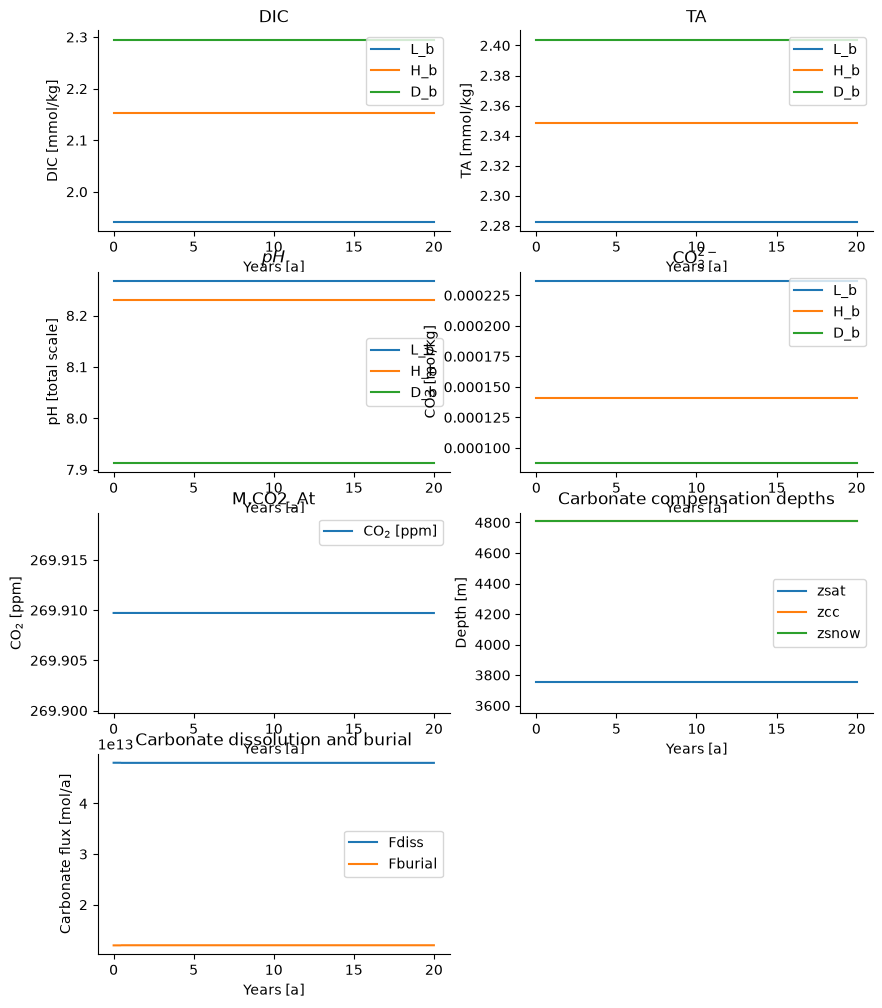

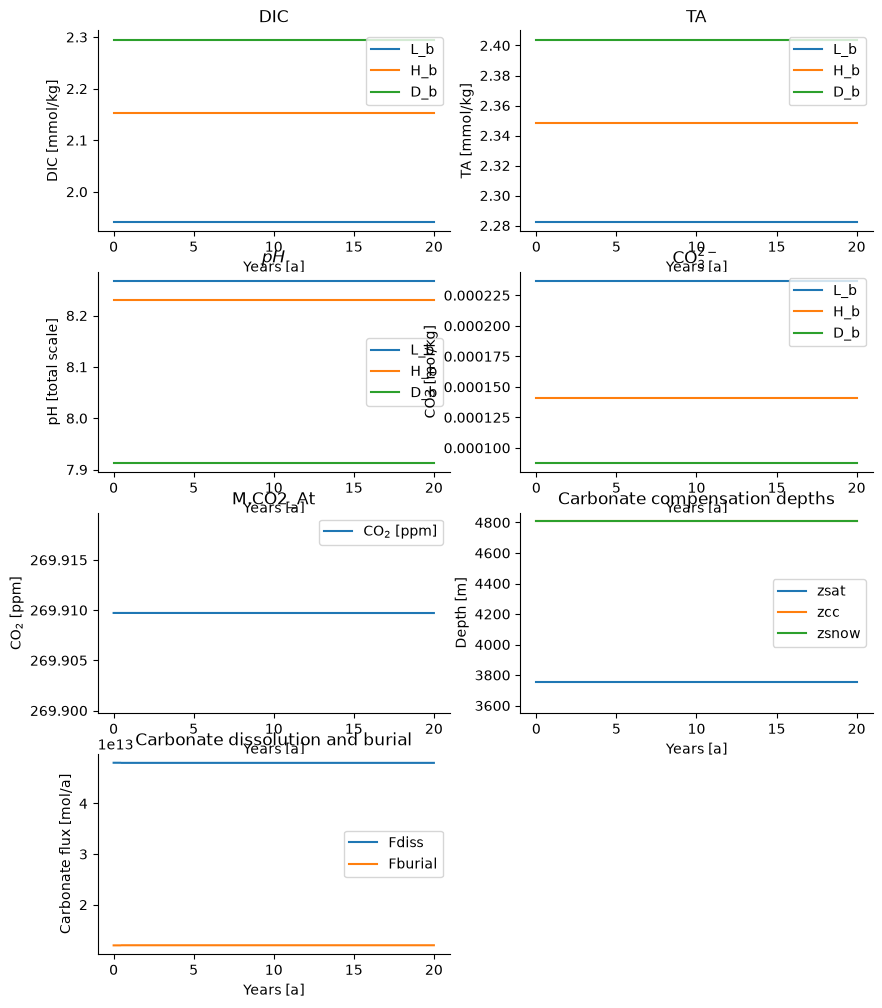

In [18]:
_, fig, _ = M.plot(
    standard_diagnostics(M),
    title='Student-built Boudreau-like model: unforced restart check',
    no_show=True,
)
fig

## 15. Instructor verification against the reusable implementation

The hidden check below constructs the repository's tested reference model independently, runs it from the same state, and compares its final values with the model assembled above. It is a verification oracle, not part of the student construction path.

In [19]:
from model import initialize_model

reference = initialize_model(P, stop='20 yr', max_timestep='1 yr')
reference.read_state(directory=str(STATE))
run_model(reference)
postprocess_carbonate_horizons(reference)

for student_value, reference_value in (
    (M.CO2_At.c[-1], reference.CO2_At.c[-1]),
    (M.L_b.DIC.c[-1], reference.L_b.DIC.c[-1]),
    (M.L_b.TA.c[-1], reference.L_b.TA.c[-1]),
    (M.D_b.DIC.c[-1], reference.D_b.DIC.c[-1]),
    (M.D_b.zcc.c[-1], reference.D_b.zcc.c[-1]),
):
    assert abs(student_value - reference_value) <= max(abs(reference_value), 1.0) * 1e-10

print('Construction verified: the student-built and reusable models agree.')


ESBMTK 0.14.3.1.post0  
 Copyright (C) 2020 - 2026  Ulrich G.Wortmann
This program comes with ABSOLUTELY NO WARRANTY
This is free software, and you are welcome to redistribute it
under certain conditions; See the LICENSE file for details.

If you use ESBMTK for your research, please cite:

Wortmann et al. 2025, https://doi.org/10.5194/gmd-18-1155-2025



INFO:root:bypassing M.Conn_L_b_to_D_b_DIC_PIC_DIC._FPIC_DIC in M.D_b.DIC
INFO:root:bypassing M.Conn_L_b_to_D_b_TA_PIC_TA._FPIC_TA in M.D_b.TA
INFO:root:creating M_L_b_cs_generic_function
INFO:root:creating M_H_b_cs_generic_function
INFO:root:creating M_D_b_cs2_generic_function
INFO:root:creating M_H_b_DIC_gas_exchangeH_b_generic_function
INFO:root:creating M_L_b_DIC_gas_exchangeL_b_generic_function
INFO:root:================================================================================
INFO:root:Intergration started at 2026-09-16 14:24:22.357065
INFO:root:r = M.H_b.DIC, r.c[0] = 2.15e-03, rtol = 2.15e-08
INFO:root:r = M.H_b.TA, r.c[0] = 2.35e-03, rtol = 2.35e-08
INFO:root:r = M.L_b.DIC, r.c[0] = 1.94e-03, rtol = 1.94e-08
INFO:root:r = M.L_b.TA, r.c[0] = 2.28e-03, rtol = 2.28e-08
INFO:root:r = M.D_b.DIC, r.c[0] = 2.30e-03, rtol = 2.30e-08
INFO:root:r = M.D_b.TA, r.c[0] = 2.40e-03, rtol = 2.40e-08
INFO:root:r = M.L_b.Hplus, r.c[0] = 5.40e-09, rtol = 5.40e-14
INFO:root:r = M.L_b.CO2aq, 

status=0
message=The solver successfully reached the end of the integration interval.


 Execution took 0.05 CPU seconds, wall time = 0.04 seconds

Construction verified: the student-built and reusable models agree.


## 16. What you should now be able to explain

1. A flux diagram specifies reservoirs, state variables, internal connections, and boundary fluxes.
2. Physical water transports carry both DIC and TA at source concentrations.
3. The soft-tissue closure carries DIC but no TA.
4. The carbonate pump requires an exact 1:2 DIC–TA pair and feeds carbonate compensation.
5. The solubility pump emerges from temperature-dependent chemistry, gas exchange, and circulation.
6. A restart supplies state, not structure; the model graph must still be correct.

Notebook 04 now treats this verified construction as infrastructure. There, students vary strengths and interpret state-dependent hypotheses without reimplementing the compatibility code.